# PFAS — HGT + XGBoost hybride **amélioré** (EPA 2024)

Version améliorée de [`04_hgt_xgboost_hybrid_epa2024.ipynb`](04_hgt_xgboost_hybrid_epa2024.ipynb).
Même dataset (**CA-PFAS-ASGWS**) et même cible (**EPA 2024 NPDWR** : MCL individuel
dépassé **ou** Indice de Risque mélange > 1). Mode prédictif (concentrations PFAS exclues).

## Améliorations apportées
1. **Features enrichies** — 48 variables (vs 20) : sol complet, hydrologie GLDAS,
   qualité de l'air AQS, plus de co-contaminants, temporel, catégoriels encodés.
   → nouveaux types de nœuds : `air`, `time`, `context`.
2. **Validation honnête (split par puits)** — `GroupShuffleSplit` sur `gm_well_id` :
   aucun échantillon d'un même puits dans train **et** test (46k lignes / 11k puits →
   le split aléatoire fuyait). Option `SPATIAL_BLOCKING` (groupe par `county`) pour un
   test encore plus strict. *Les scores baissent mais reflètent la vraie généralisation.*
3. **Arêtes `sample↔sample` (KNN spatial)** — le graphe initial n'avait que des
   auto-boucles 1:1 (aucun passage de message entre puits). On ajoute les k plus
   proches voisins spatiaux → le HGT exploite enfin la structure.
4. **Sans SMOTE** — données quasi-équilibrées ; on utilise `scale_pos_weight`
   (l'analyse de sensibilité du notebook 04 montrait que SMOTE *dégradait* le F1).
5. **Seuil + calibration** — seuil de décision optimisé sur la validation (max F1) et
   **calibration isotonique** des probabilités du stacking (+ score de Brier).
6. **Stacking sans fuite (OOF)** — méta-features d'entraînement des GBM générées par
   `cross_val_predict` (out-of-fold).

> Noyau : `pfas_torch` (PyTorch + PyTorch Geometric, py3.10). CPU.

## 1. Imports et configuration

In [1]:
import warnings, json, pickle
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
import torch, torch.nn as nn, torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import HGTConv, Linear
    TORCH_GEOMETRIC_AVAILABLE = True; print('PyTorch Geometric disponible')
except ImportError:
    TORCH_GEOMETRIC_AVAILABLE = False; print('PyTorch Geometric NON disponible')
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (classification_report, roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score, brier_score_loss, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
import xgboost as xgb, lightgbm as lgb, optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(42); torch.manual_seed(42)
PROJECT_ROOT = Path('..'); PROCESSED_DIR = PROJECT_ROOT/'data'/'processed'
FIG_DIR = PROJECT_ROOT/'reports'/'figures'/'hgt_hybrid_improved'
RES_DIR = PROJECT_ROOT/'outputs'/'hgt_hybrid_improved'; MODELS_DIR = PROJECT_ROOT/'models'
for d in (FIG_DIR, RES_DIR, MODELS_DIR): d.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
EPOCHS_HGT = 70           # epochs HGT
N_TRIALS = 12             # essais Optuna (fusion / stacking)
RUN_OPTUNA_HGT = False
SPATIAL_BLOCKING = False   # True = split groupé par county (plus strict que par puits)
print(f'Device: {device} | torch {torch.__version__}')

PyTorch Geometric disponible


Device: cpu | torch 2.11.0+cu130


## 2. Chargement des données et cible EPA 2024 (identiques au notebook de référence)

Dataset: 46,338 lignes x 202 cols | puits uniques: 11,333
Class 0: 25184 (54.3%) | Class 1: 21154 (45.7%)


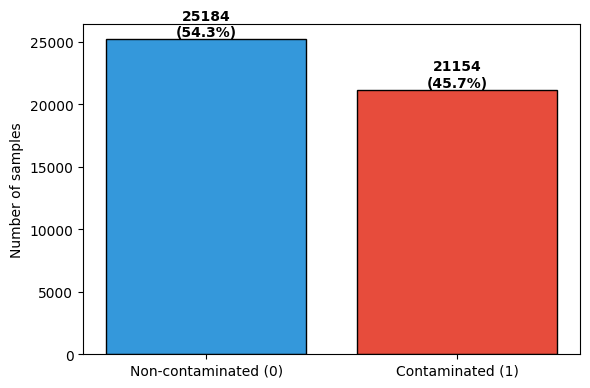

In [2]:
df = pd.read_csv(PROCESSED_DIR/'CA-PFAS-ASGWS.csv')
EPA2024_MCLS = {'PFOA_ngL':4.0,'PFOS_ngL':4.0,'PFNA_ngL':10.0,'PFHxS_ngL':10.0,'HFPO_DA_ngL':10.0}
HI_REFS      = {'PFNA_ngL':10.0,'PFHxS_ngL':10.0,'HFPO_DA_ngL':10.0,'PFBS_ngL':2000.0}
def compute_target_epa2024(d):
    ex = pd.Series(False, index=d.index)
    for c,m in EPA2024_MCLS.items():
        if c in d.columns: ex |= d[c].fillna(0) > m
    ex |= sum(d[c].fillna(0)/r for c,r in HI_REFS.items() if c in d.columns) > 1.0
    return ex.astype(int)
df['is_contaminated'] = compute_target_epa2024(df)
print(f'Dataset: {df.shape[0]:,} lignes x {df.shape[1]} cols | puits uniques: {df.gm_well_id.nunique():,}')
print(f"Class 0: {(df.is_contaminated==0).sum()} ({(df.is_contaminated==0).mean()*100:.1f}%) | "
      f"Class 1: {(df.is_contaminated==1).sum()} ({(df.is_contaminated==1).mean()*100:.1f}%)")
counts = df['is_contaminated'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(['Non-contaminated (0)','Contaminated (1)'], counts.values, color=['#3498db','#e74c3c'], edgecolor='black')
for b,v in zip(bars, counts.values): ax.text(b.get_x()+b.get_width()/2., b.get_height(), f'{v}\n({100*v/len(df):.1f}%)', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Number of samples'); plt.tight_layout()
plt.savefig(FIG_DIR/'fig1_class_distribution.png', dpi=300, bbox_inches='tight'); plt.show()

## 3. Features enrichies (48) + nouveaux types de nœuds

On passe de 20 à **48 features** réparties en 7 groupes (PFAS toujours exclus).
Les catégoriels sont encodés en ordinal ; deux features dérivées
(`sand_silt_ratio`, `geotracker_proximity`) sont conservées.

In [3]:
df['sand_silt_ratio']      = df['soil_sand_pct'] / (df['soil_silt_pct'] + 1e-6)
df['geotracker_proximity'] = 1.0 / (1.0 + df['dist_geotracker_km'])
dt = pd.to_datetime(df['collection_date'])
df['year'] = dt.dt.year; df['month'] = dt.dt.month; df['season'] = ((dt.dt.month % 12)//3 + 1).astype(int)
CAT = ['gm_well_category','nearest_geotracker_type','county']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[[c+'_enc' for c in CAT]] = oe.fit_transform(df[CAT].astype(str))

FEATURE_CATEGORIES = {
 'Environmental': ['rainfall_mm_month','runoff_mm','et_mm_month','soil_moisture_total_mm',
   'root_zone_moist_kg_m2','temp_c','snowpack_mm','soil_sand_pct','soil_silt_pct','soil_clay_pct',
   'soil_om_pct','soil_ph','soil_ksat_um_s','soil_awc_cm_cm','soil_bulk_density','sand_silt_ratio'],
 'Facility_Proximity': ['dist_geotracker_km','n_geotracker_within_1km','n_geotracker_within_3km',
   'n_geotracker_within_10km','n_geotracker_within_50km','geotracker_proximity'],
 'Water_Quality': ['cocontam_tds','cocontam_no3n','cocontam_so4','cocontam_tce','cocontam_pce',
   'cocontam_mtbe','cocontam_as','cocontam_mn','cocontam_fe','cocontam_bz'],
 'Air_Quality': ['aqs_pm25_ugm3','aqs_pm10_ugm3','aqs_no2_ppb','aqs_so2_ppb','aqs_ozone_ppb',
   'aqs_co_ppm','aqs_wind_ms','aqs_humidity_pct'],
 'Temporal': ['year','month','season'],
 'Context': [c+'_enc' for c in CAT],
 'Geospatial': ['latitude','longitude'],
}
all_feature_cols = []
for v in FEATURE_CATEGORIES.values(): all_feature_cols += [f for f in v if f in df.columns]
all_feature_cols = list(dict.fromkeys(all_feature_cols))
for cat, feats in FEATURE_CATEGORIES.items():
    print(f'  {cat:20s}: {len([f for f in feats if f in df.columns])}/{len(feats)}')
print(f'Total features: {len(all_feature_cols)}')

  Environmental       : 16/16
  Facility_Proximity  : 6/6
  Water_Quality       : 10/10
  Air_Quality         : 8/8
  Temporal            : 3/3
  Context             : 3/3
  Geospatial          : 2/2
Total features: 48


## 4. Split **par puits** (validation honnête) + normalisation, sans SMOTE

`GroupShuffleSplit` garantit qu'aucun puits (`gm_well_id`) n'apparaît dans deux
sous-ensembles → pas de fuite « même puits ». Données quasi-équilibrées : pas de
SMOTE, on passe `scale_pos_weight` aux GBM et des poids de classe au HGT.

In [4]:
X = df[all_feature_cols].copy().fillna(0); y = df['is_contaminated'].copy()
groups = df['county'].values if SPATIAL_BLOCKING else df['gm_well_id'].values
gss = GroupShuffleSplit(1, test_size=0.2, random_state=42); full_idx, test_idx = next(gss.split(X, y, groups))
gss2 = GroupShuffleSplit(1, test_size=0.25, random_state=42)
tr_rel, val_rel = next(gss2.split(X.iloc[full_idx], y.iloc[full_idx], groups[full_idx]))
tr_idx, val_idx = full_idx[tr_rel], full_idx[val_rel]
X_train, X_val, X_test = X.iloc[tr_idx], X.iloc[val_idx], X.iloc[test_idx]
y_train = y.iloc[tr_idx].reset_index(drop=True); y_val = y.iloc[val_idx].reset_index(drop=True); y_test = y.iloc[test_idx].reset_index(drop=True)
gtr, gva, gte = set(groups[tr_idx]), set(groups[val_idx]), set(groups[test_idx])
print(f'Split groupé par {"county" if SPATIAL_BLOCKING else "gm_well_id"} | overlap tr/test={len(gtr&gte)} tr/val={len(gtr&gva)}')
print(f'Train {len(X_train)} ({100*y_train.mean():.1f}% pos) | Val {len(X_val)} ({100*y_val.mean():.1f}%) | Test {len(X_test)} ({100*y_test.mean():.1f}%)')
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train); X_val_s = scaler.transform(X_val); X_test_s = scaler.transform(X_test)
scale_pos_weight = float((y_train==0).sum()/(y_train==1).sum())
print(f'scale_pos_weight = {scale_pos_weight:.3f} (remplace SMOTE)')

Split groupé par gm_well_id | overlap tr/test=0 tr/val=0
Train 27894 (46.5% pos) | Val 9264 (45.0%) | Test 9180 (43.8%)
scale_pos_weight = 1.152 (remplace SMOTE)


## 5–6. Graphe hétérogène avec arêtes `sample↔sample` (KNN spatial)

`KMeans` (clusters géo) et `NearestNeighbors` (KNN spatial) **fittés sur le train**.
Chaque graphe reçoit ses propres arêtes `near_sample` (KNN intra-split) → vrai passage
de message entre puits voisins, en plus des liens vers les nœuds env/facility/water/air/time/context/geo.

In [5]:
def fit_graph_transformers(X_train_df, n_geo_clusters=20, knn_k=6):
    t = {}; coords = X_train_df[['latitude','longitude']].values.astype(np.float32)
    n = min(n_geo_clusters, max(2, len(X_train_df)//50))
    t['kmeans'] = KMeans(n, random_state=42, n_init=10).fit(coords); t['knn_k'] = knn_k
    print(f'KMeans: {n} clusters | KNN spatial k={knn_k}'); return t

def knn_edges(coords, k):
    k = min(k+1, len(coords)); nn = NearestNeighbors(n_neighbors=k).fit(coords); _, idx = nn.kneighbors(coords)
    src = np.repeat(np.arange(len(coords)), idx.shape[1]-1); dst = idx[:,1:].reshape(-1)
    e = np.stack([src, dst]); return np.concatenate([e, e[::-1]], axis=1)  # undirected

def create_heterogeneous_graph(X_data, y_data, fc, transformers):
    d = HeteroData(); n = len(X_data)
    d['sample'].x = torch.FloatTensor(X_data.values); d['sample'].y = torch.LongTensor(np.asarray(y_data))
    ei = torch.stack([torch.arange(n), torch.arange(n)], 0)
    spec = {'Environmental':('env','has_env','affects'),'Facility_Proximity':('facility','near','near_to'),
            'Water_Quality':('water','quality','measured_in'),'Air_Quality':('air','breathes','over'),
            'Temporal':('time','sampled_at','at'),'Context':('context','described_by','describes')}
    for key,(nt,e1,e2) in spec.items():
        feats = [f for f in fc.get(key,[]) if f in X_data.columns]
        if feats:
            d[nt].x = torch.FloatTensor(X_data[feats].values)
            d['sample',e1,nt].edge_index = ei; d[nt,e2,'sample'].edge_index = ei
    km = transformers['kmeans']; coords = X_data[['latitude','longitude']].values.astype(np.float32); lab = km.predict(coords)
    d['geo_cluster'].x = torch.FloatTensor(km.cluster_centers_.astype(np.float32)); src = np.arange(n)
    d['sample','located_in','geo_cluster'].edge_index = torch.tensor([src,lab], dtype=torch.long)
    d['geo_cluster','contains','sample'].edge_index = torch.tensor([lab,src], dtype=torch.long)
    ke = knn_edges(coords, transformers['knn_k'])
    d['sample','near_sample','sample'].edge_index = torch.tensor(ke, dtype=torch.long)
    return d

if TORCH_GEOMETRIC_AVAILABLE:
    transformers = fit_graph_transformers(pd.DataFrame(X_train_s, columns=X_train.columns))
    train_data = create_heterogeneous_graph(pd.DataFrame(X_train_s, columns=X_train.columns), y_train, FEATURE_CATEGORIES, transformers)
    val_data   = create_heterogeneous_graph(pd.DataFrame(X_val_s, columns=X_val.columns), y_val, FEATURE_CATEGORIES, transformers)
    test_data  = create_heterogeneous_graph(pd.DataFrame(X_test_s, columns=X_test.columns), y_test, FEATURE_CATEGORIES, transformers)
    print('Node types:', list(train_data.node_types))
    print('Edge types:', len(train_data.edge_types),
          '| arêtes sample-sample (train):', train_data['sample','near_sample','sample'].edge_index.shape[1])

KMeans: 20 clusters | KNN spatial k=6


Node types: ['sample', 'env', 'facility', 'water', 'air', 'time', 'context', 'geo_cluster']
Edge types: 15 | arêtes sample-sample (train): 334728


## 7. Modèle HGT + entraînement (poids de classe, augmentation de graphe)

In [6]:
class HGT_Classifier(nn.Module):
    def __init__(self, metadata, hidden_channels=64, out_channels=2, num_heads=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.lin_dict = nn.ModuleDict({nt: Linear(-1, hidden_channels) for nt in metadata[0]})
        self.convs = nn.ModuleList([HGTConv(hidden_channels, hidden_channels, metadata, heads=num_heads) for _ in range(num_layers)])
        self.classifier = nn.Sequential(nn.Linear(hidden_channels, hidden_channels//2), nn.ReLU(),
                                        nn.Dropout(dropout), nn.Linear(max(1,hidden_channels//2), out_channels))
    def forward(self, x_dict, edge_index_dict, return_embeddings=False):
        x_dict = {nt: self.lin_dict[nt](x).relu_() for nt, x in x_dict.items()}
        for conv in self.convs: x_dict = conv(x_dict, edge_index_dict)
        emb = x_dict['sample']
        return emb if return_embeddings else self.classifier(emb)

def augment_hetero_graph(x_dict, edge_dict, noise=0.01, drop=0.1):
    xa = {nt: x + noise*torch.randn_like(x) for nt, x in x_dict.items()}; ea = {}
    for et, e in edge_dict.items():
        E = e.size(1); keep = (torch.rand(E) > drop).nonzero(as_tuple=True)[0]; ea[et] = e if keep.numel()==0 else e[:, keep]
    return xa, ea

def train_hgt(model, train_data, val_data, epochs, lr=3e-3, weight_decay=1e-5, verbose=True):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    cc = np.bincount(train_data['sample'].y.numpy()); cw = torch.FloatTensor([1.0/c for c in cc]); cw = cw/cw.sum()
    crit = nn.CrossEntropyLoss(weight=cw); sch = ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=10)
    txd = {nt: train_data[nt].x for nt in train_data.node_types}; ted = {et: train_data[et].edge_index for et in train_data.edge_types}; ty = train_data['sample'].y
    vxd = {nt: val_data[nt].x for nt in val_data.node_types}; ved = {et: val_data[et].edge_index for et in val_data.edge_types}; vy = val_data['sample'].y
    best = 0; best_state = None; hist = {'train_loss':[], 'val_f1':[]}
    for ep in range(1, epochs+1):
        model.train(); opt.zero_grad(); xa, ea = augment_hetero_graph(txd, ted); out = model(xa, ea)
        loss = crit(out, ty); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad(): vp = model(vxd, ved).argmax(1); vf1 = f1_score(vy.cpu(), vp.cpu())
        sch.step(vf1); hist['train_loss'].append(loss.item()); hist['val_f1'].append(vf1)
        if vf1 > best: best = vf1; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if verbose and (ep % 10 == 0 or ep == 1): print(f'Epoch {ep:3d}/{epochs} | Loss {loss:.4f} | Val F1 {vf1:.4f}')
    if best_state: model.load_state_dict(best_state)
    if verbose: print(f'Meilleur Val F1: {best:.4f}')
    return model, hist

if TORCH_GEOMETRIC_AVAILABLE:
    metadata = train_data.metadata()
    hgt_model = HGT_Classifier(metadata).to(device)
    with torch.no_grad():
        _ = hgt_model({nt: train_data[nt].x for nt in train_data.node_types},
                      {et: train_data[et].edge_index for et in train_data.edge_types})
    print(f'HGT — {sum(p.numel() for p in hgt_model.parameters()):,} paramètres')
    hgt_model, hgt_history = train_hgt(hgt_model, train_data, val_data, EPOCHS_HGT)

HGT — 336,618 paramètres


Epoch   1/70 | Loss 0.6940 | Val F1 0.0000


Epoch  10/70 | Loss 0.6475 | Val F1 0.5946


Epoch  20/70 | Loss 0.6119 | Val F1 0.6724


Epoch  30/70 | Loss 0.5451 | Val F1 0.6869


Epoch  40/70 | Loss 0.4765 | Val F1 0.6897


Epoch  50/70 | Loss 0.4214 | Val F1 0.7116


Epoch  60/70 | Loss 0.4068 | Val F1 0.7120


Epoch  70/70 | Loss 0.3788 | Val F1 0.7251
Meilleur Val F1: 0.7251


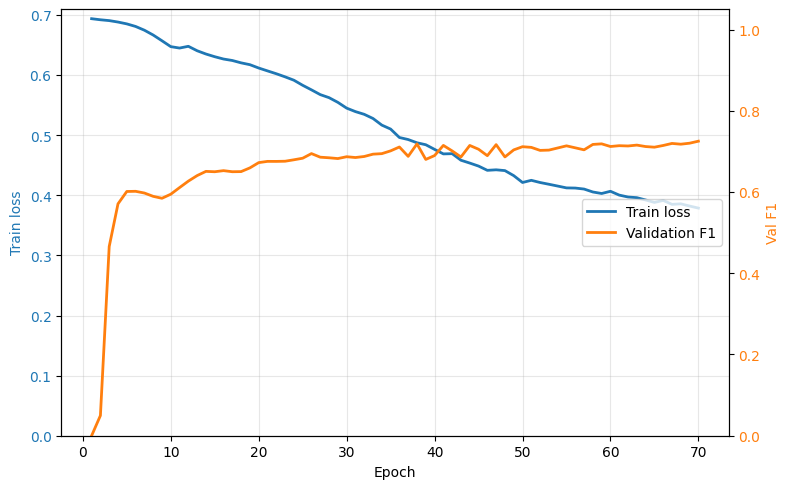

In [7]:
# Figure — courbe d'apprentissage HGT
if TORCH_GEOMETRIC_AVAILABLE:
    ep = range(1, len(hgt_history['train_loss'])+1)
    fig, ax1 = plt.subplots(figsize=(8,5)); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Train loss', color='tab:blue')
    l1 = ax1.plot(ep, hgt_history['train_loss'], color='tab:blue', lw=2, label='Train loss')
    ax1.tick_params(axis='y', labelcolor='tab:blue'); ax1.grid(alpha=0.3); ax1.set_ylim(bottom=0)
    ax2 = ax1.twinx(); ax2.set_ylabel('Val F1', color='tab:orange'); ax2.set_ylim([0,1.05])
    l2 = ax2.plot(ep, hgt_history['val_f1'], color='tab:orange', lw=2, label='Validation F1')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    ax1.legend(l1+l2, [x.get_label() for x in l1+l2], loc='center right'); fig.tight_layout()
    plt.savefig(FIG_DIR/'fig3_hgt_learning_curve.png', dpi=300, bbox_inches='tight'); plt.show()

## 8. Modèles de base : XGBoost + LightGBM (`scale_pos_weight`, sans SMOTE)

In [8]:
xgb_baseline = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.08, subsample=0.8,
    colsample_bytree=0.8, scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb_baseline.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)
lgb_model = lgb.LGBMClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, num_leaves=31, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1, scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1)
lgb_model.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], callbacks=[lgb.log_evaluation(0)])
print('XGBoost F1:', round(f1_score(y_test, xgb_baseline.predict(X_test_s)),4),
      '| LightGBM F1:', round(f1_score(y_test, lgb_model.predict(X_test_s)),4))

XGBoost F1: 0.7743 | LightGBM F1: 0.7829


## 9. Helpers (embeddings / probas HGT) + recherche de seuil optimal

In [9]:
def hgt_embeddings(model, data):
    model.eval()
    with torch.no_grad():
        return model({nt: data[nt].x for nt in data.node_types}, {et: data[et].edge_index for et in data.edge_types}, return_embeddings=True).cpu().numpy()
def hgt_proba(model, data):
    model.eval()
    with torch.no_grad():
        return F.softmax(model({nt: data[nt].x for nt in data.node_types}, {et: data[et].edge_index for et in data.edge_types}), 1).cpu().numpy()
def best_threshold(y_val, proba_val):
    ts = np.linspace(0.1, 0.9, 81)
    return float(ts[int(np.argmax([f1_score(y_val, (proba_val>=t).astype(int)) for t in ts]))])

if TORCH_GEOMETRIC_AVAILABLE:
    train_emb = hgt_embeddings(hgt_model, train_data); val_emb = hgt_embeddings(hgt_model, val_data); test_emb = hgt_embeddings(hgt_model, test_data)
    hgt_proba_val = hgt_proba(hgt_model, val_data)[:,1]; hgt_proba_test = hgt_proba(hgt_model, test_data)[:,1]

## 10. APPROCHE 1 — Embedding Fusion (HGT → PCA → XGBoost)

In [10]:
if TORCH_GEOMETRIC_AVAILABLE:
    pca_emb = PCA(0.95, random_state=42)
    train_emb_pca = pca_emb.fit_transform(train_emb); val_emb_pca = pca_emb.transform(val_emb); test_emb_pca = pca_emb.transform(test_emb)
    X_train_fusion = np.concatenate([X_train_s, train_emb_pca], 1)
    X_val_fusion   = np.concatenate([X_val_s,   val_emb_pca],   1)
    X_test_fusion  = np.concatenate([X_test_s,  test_emb_pca],  1)
    print(f'Fusion: {X_train_fusion.shape[1]} dims ({X_train_s.shape[1]} features + {train_emb_pca.shape[1]} emb PCA)')
    def objective_fusion(t):
        p = dict(n_estimators=t.suggest_int('n_estimators',150,600), max_depth=t.suggest_int('max_depth',3,12),
            learning_rate=t.suggest_float('learning_rate',0.01,0.3,log=True), subsample=t.suggest_float('subsample',0.5,1.0),
            colsample_bytree=t.suggest_float('colsample_bytree',0.4,1.0), min_child_weight=t.suggest_int('min_child_weight',1,10),
            gamma=t.suggest_float('gamma',0,1.0), reg_alpha=t.suggest_float('reg_alpha',1e-4,1.0,log=True),
            reg_lambda=t.suggest_float('reg_lambda',1e-4,2.0,log=True), scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
        c = xgb.XGBClassifier(**p); c.fit(X_train_fusion, y_train, eval_set=[(X_val_fusion, y_val)], verbose=False)
        return f1_score(y_val, c.predict(X_val_fusion))
    sf = optuna.create_study(direction='maximize'); sf.optimize(objective_fusion, n_trials=N_TRIALS, show_progress_bar=True)
    bp = dict(sf.best_params); bp.update(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
    xgb_fusion = xgb.XGBClassifier(**bp); xgb_fusion.fit(X_train_fusion, y_train, eval_set=[(X_val_fusion, y_val)], verbose=False)
    fusion_proba_val = xgb_fusion.predict_proba(X_val_fusion)[:,1]; fusion_proba_test = xgb_fusion.predict_proba(X_test_fusion)[:,1]
    print('Fusion F1:', round(f1_score(y_test, (fusion_proba_test>=0.5).astype(int)),4), '| AUC:', round(roc_auc_score(y_test, fusion_proba_test),4))

Fusion: 50 dims (48 features + 2 emb PCA)


  0%|          | 0/12 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.763125:   0%|          | 0/12 [00:02<?, ?it/s]

Best trial: 0. Best value: 0.763125:   8%|▊         | 1/12 [00:02<00:28,  2.58s/it]

Best trial: 0. Best value: 0.763125:   8%|▊         | 1/12 [00:05<00:28,  2.58s/it]

...

Best trial: 0. Best value: 0.763125:  92%|█████████▏| 11/12 [00:48<00:04,  4.46s/it]

Best trial: 0. Best value: 0.763125:  92%|█████████▏| 11/12 [00:54<00:04,  4.46s/it]

Best trial: 0. Best value: 0.763125: 100%|██████████| 12/12 [00:54<00:00,  5.07s/it]

Best trial: 0. Best value: 0.763125: 100%|██████████| 12/12 [00:54<00:00,  4.57s/it]

Fusion F1: 0.8157 | AUC: 0.9156


## 11. APPROCHE 2 — Stacking **out-of-fold** + calibration isotonique

Les méta-features d'entraînement des GBM sont générées par `cross_val_predict`
(out-of-fold) pour éviter que le méta-classifieur n'apprenne sur des prédictions
in-sample. Les probabilités finales du stacking sont **calibrées** (isotonique, fittée
sur la validation).

In [11]:
if TORCH_GEOMETRIC_AVAILABLE:
    skf = StratifiedKFold(5, shuffle=True, random_state=42)
    xgb_oof = cross_val_predict(xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.08, subsample=0.8,
        colsample_bytree=0.8, scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'),
        X_train_s, y_train, cv=skf, method='predict_proba')
    lgb_oof = cross_val_predict(lgb.LGBMClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1, scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1),
        X_train_s, y_train, cv=skf, method='predict_proba')
    hgt_p_tr = hgt_proba(hgt_model, train_data); hgt_p_va = hgt_proba(hgt_model, val_data); hgt_p_te = hgt_proba(hgt_model, test_data)
    xgb_p_va = xgb_baseline.predict_proba(X_val_s); xgb_p_te = xgb_baseline.predict_proba(X_test_s)
    lgb_p_va = lgb_model.predict_proba(X_val_s);   lgb_p_te = lgb_model.predict_proba(X_test_s)
    pca_meta = PCA(0.90, random_state=42); etr = pca_meta.fit_transform(train_emb); eva = pca_meta.transform(val_emb); ete = pca_meta.transform(test_emb)
    def build_meta(h, x, l, e):
        eps = 1e-10; h1, x1, l1 = h[:,1:2], x[:,1:2], l[:,1:2]
        he = (-h*np.log(h+eps)).sum(1,keepdims=True); xe = (-x*np.log(x+eps)).sum(1,keepdims=True); le = (-l*np.log(l+eps)).sum(1,keepdims=True)
        return np.hstack([h1, x1, l1, he, xe, le, h.max(1,keepdims=True), x.max(1,keepdims=True), l.max(1,keepdims=True),
                          np.abs(h1-x1), np.abs(x1-l1), h1*x1, np.maximum(x1,l1), 0.3*h1+0.4*x1+0.3*l1, e])
    meta_train = build_meta(hgt_p_tr, xgb_oof, lgb_oof, etr)   # OOF pour les GBM
    meta_val   = build_meta(hgt_p_va, xgb_p_va, lgb_p_va, eva)
    meta_test  = build_meta(hgt_p_te, xgb_p_te, lgb_p_te, ete)
    print(f'Méta-features: {meta_train.shape[1]} dims')
    def objective_stacking(t):
        p = dict(n_estimators=t.suggest_int('n_estimators',50,300), max_depth=t.suggest_int('max_depth',2,7),
            learning_rate=t.suggest_float('learning_rate',0.01,0.2,log=True), subsample=t.suggest_float('subsample',0.5,1.0),
            colsample_bytree=t.suggest_float('colsample_bytree',0.5,1.0), min_child_weight=t.suggest_int('min_child_weight',1,8),
            reg_alpha=t.suggest_float('reg_alpha',1e-4,0.5,log=True), reg_lambda=t.suggest_float('reg_lambda',1e-4,1.0,log=True),
            scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
        c = xgb.XGBClassifier(**p); c.fit(meta_train, y_train, eval_set=[(meta_val, y_val)], verbose=False)
        return f1_score(y_val, c.predict(meta_val))
    ss = optuna.create_study(direction='maximize'); ss.optimize(objective_stacking, n_trials=N_TRIALS, show_progress_bar=True)
    bmp = dict(ss.best_params); bmp.update(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
    meta_clf = xgb.XGBClassifier(**bmp); meta_clf.fit(meta_train, y_train, eval_set=[(meta_val, y_val)], verbose=False)
    stack_proba_val = meta_clf.predict_proba(meta_val)[:,1]; stack_proba_test = meta_clf.predict_proba(meta_test)[:,1]
    iso = IsotonicRegression(out_of_bounds='clip').fit(stack_proba_val, y_val)
    stack_proba_val_cal = iso.transform(stack_proba_val); stack_proba_test_cal = iso.transform(stack_proba_test)
    print('Stacking F1:', round(f1_score(y_test, (stack_proba_test>=0.5).astype(int)),4),
          '| Brier brut:', round(brier_score_loss(y_test, stack_proba_test),4),
          '| Brier calibré:', round(brier_score_loss(y_test, stack_proba_test_cal),4))

Méta-features: 15 dims


  0%|          | 0/12 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.76803:   0%|          | 0/12 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.76803:   8%|▊         | 1/12 [00:00<00:04,  2.49it/s]

Best trial: 1. Best value: 0.770631:   8%|▊         | 1/12 [00:01<00:04,  2.49it/s]

...

Best trial: 6. Best value: 0.772068:  92%|█████████▏| 11/12 [00:10<00:01,  1.07s/it]

Best trial: 6. Best value: 0.772068:  92%|█████████▏| 11/12 [00:11<00:01,  1.07s/it]

Best trial: 6. Best value: 0.772068: 100%|██████████| 12/12 [00:11<00:00,  1.06s/it]

Best trial: 6. Best value: 0.772068: 100%|██████████| 12/12 [00:11<00:00,  1.05it/s]

Stacking F1: 0.7805 | Brier brut: 0.1404 | Brier calibré: 0.1317


## 12. Comparaison — seuil 0.5 vs seuil optimisé, AUC et calibration (Brier)

           Model  thr   F1@0.5   F1@thr  Precision@thr  Recall@thr  ROC_AUC    Brier
             HGT 0.29 0.781199 0.780069       0.723237    0.846594 0.879454 0.138187
         XGBoost 0.36 0.774347 0.780530       0.777641    0.783441 0.893504 0.133390
        LightGBM 0.33 0.782926 0.778057       0.750636    0.807558 0.895161 0.129286
Embedding Fusion 0.33 0.815662 0.814613       0.778861    0.853804 0.915564 0.116437
        Stacking 0.27 0.780539 0.782312       0.766898    0.798359 0.890022 0.140366
  Stacking+calib 0.39 0.771269 0.779580       0.788603    0.770761 0.888909 0.131669


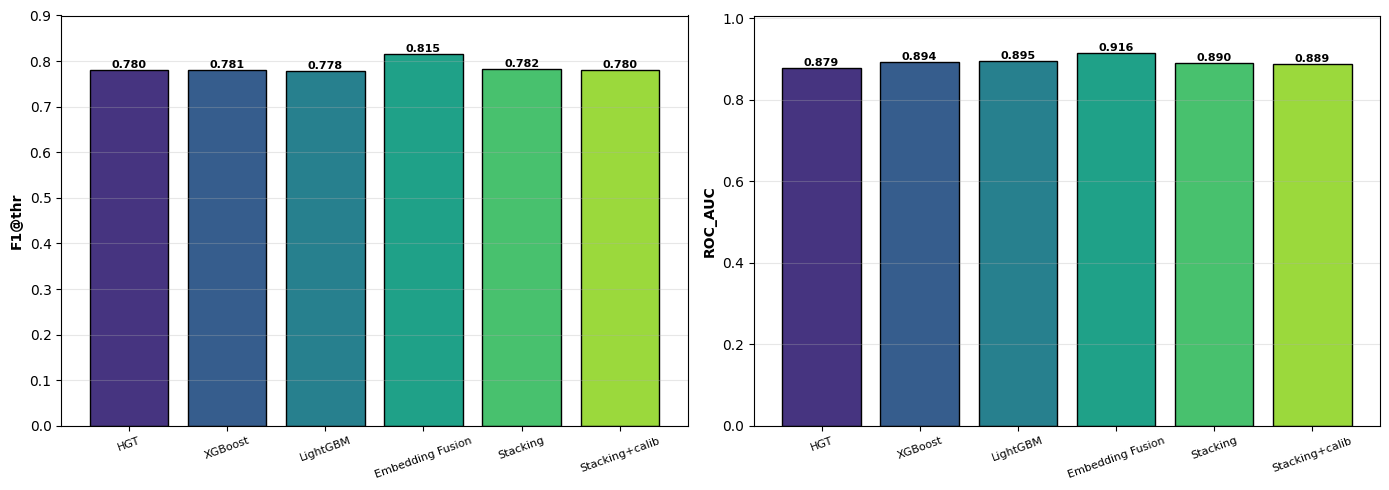

Meilleur modèle (F1@thr): Embedding Fusion = 0.8146


In [12]:
if TORCH_GEOMETRIC_AVAILABLE:
    models = [
        ('HGT',            hgt_proba_val,        hgt_proba_test),
        ('XGBoost',        xgb_baseline.predict_proba(X_val_s)[:,1], xgb_baseline.predict_proba(X_test_s)[:,1]),
        ('LightGBM',       lgb_model.predict_proba(X_val_s)[:,1],    lgb_model.predict_proba(X_test_s)[:,1]),
        ('Embedding Fusion', fusion_proba_val,   fusion_proba_test),
        ('Stacking',       stack_proba_val,      stack_proba_test),
        ('Stacking+calib', stack_proba_val_cal,  stack_proba_test_cal),
    ]
    rows = []
    for name, pv, pte in models:
        thr = best_threshold(y_val, pv)
        yp05 = (pte>=0.5).astype(int); ypt = (pte>=thr).astype(int)
        rows.append({'Model':name, 'thr':round(thr,3), 'F1@0.5':f1_score(y_test, yp05), 'F1@thr':f1_score(y_test, ypt),
                     'Precision@thr':precision_score(y_test, ypt), 'Recall@thr':recall_score(y_test, ypt),
                     'ROC_AUC':roc_auc_score(y_test, pte), 'Brier':brier_score_loss(y_test, pte)})
    results = pd.DataFrame(rows)
    print(results.to_string(index=False))

    # bars: F1@thr et ROC_AUC
    fig, axes = plt.subplots(1, 2, figsize=(14,5)); cols = plt.cm.viridis(np.linspace(0.15,0.85,len(results)))
    for ax, metric in zip(axes, ['F1@thr','ROC_AUC']):
        b = ax.bar(results['Model'], results[metric], color=cols, edgecolor='black')
        ax.set_ylabel(metric, fontweight='bold'); ax.set_ylim([0, max(0.9, results[metric].max()*1.1)])
        ax.tick_params(axis='x', rotation=20, labelsize=8); ax.grid(axis='y', alpha=0.3)
        for bb in b: ax.text(bb.get_x()+bb.get_width()/2., bb.get_height(), f'{bb.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    plt.tight_layout(); plt.savefig(FIG_DIR/'fig4_models_comparison.png', dpi=300, bbox_inches='tight'); plt.show()
    best_idx = results['F1@thr'].idxmax()
    print(f"Meilleur modèle (F1@thr): {results.loc[best_idx,'Model']} = {results.loc[best_idx,'F1@thr']:.4f}")

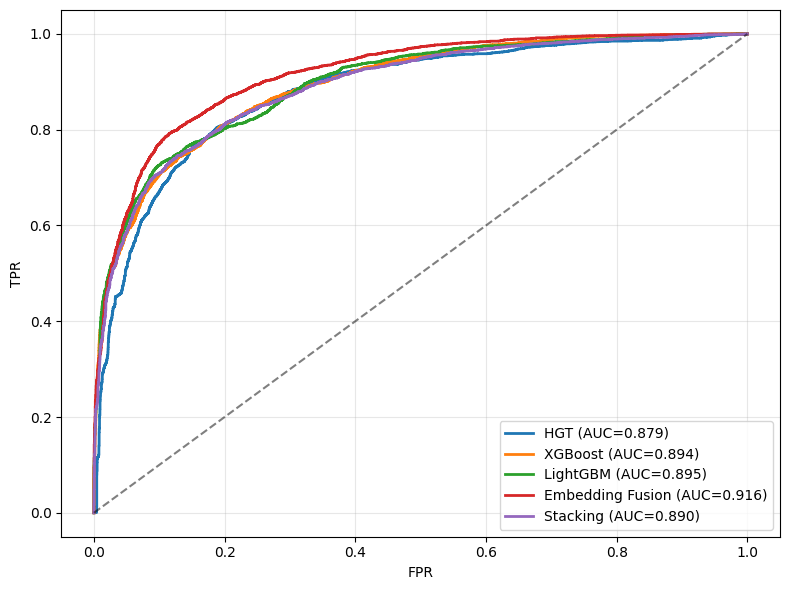

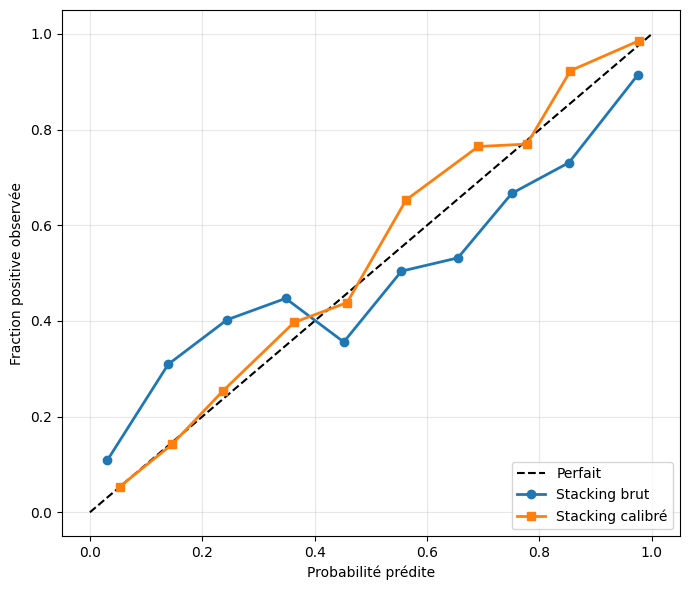

In [13]:
# ROC + calibration (stacking brut vs calibré)
if TORCH_GEOMETRIC_AVAILABLE:
    plt.figure(figsize=(8,6))
    for name, _, pte in models:
        if name == 'Stacking+calib': continue
        fpr, tpr, _ = roc_curve(y_test, pte); plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc_score(y_test, pte):.3f})')
    plt.plot([0,1],[0,1],'k--',alpha=0.5); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(loc='lower right'); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(FIG_DIR/'fig5_roc_curves.png', dpi=300, bbox_inches='tight'); plt.show()

    plt.figure(figsize=(7,6)); plt.plot([0,1],[0,1],'k--',label='Perfait')
    for proba, lab, mk in [(stack_proba_test,'Stacking brut','o-'), (stack_proba_test_cal,'Stacking calibré','s-')]:
        pt, pp = calibration_curve(y_test, proba, n_bins=10); plt.plot(pp, pt, mk, lw=2, label=lab)
    plt.xlabel('Probabilité prédite'); plt.ylabel('Fraction positive observée'); plt.legend(loc='lower right'); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(FIG_DIR/'fig_calibration_stacking.png', dpi=300, bbox_inches='tight'); plt.show()

## 13. Importance des features (XGBoost SHAP + HGT par groupe)

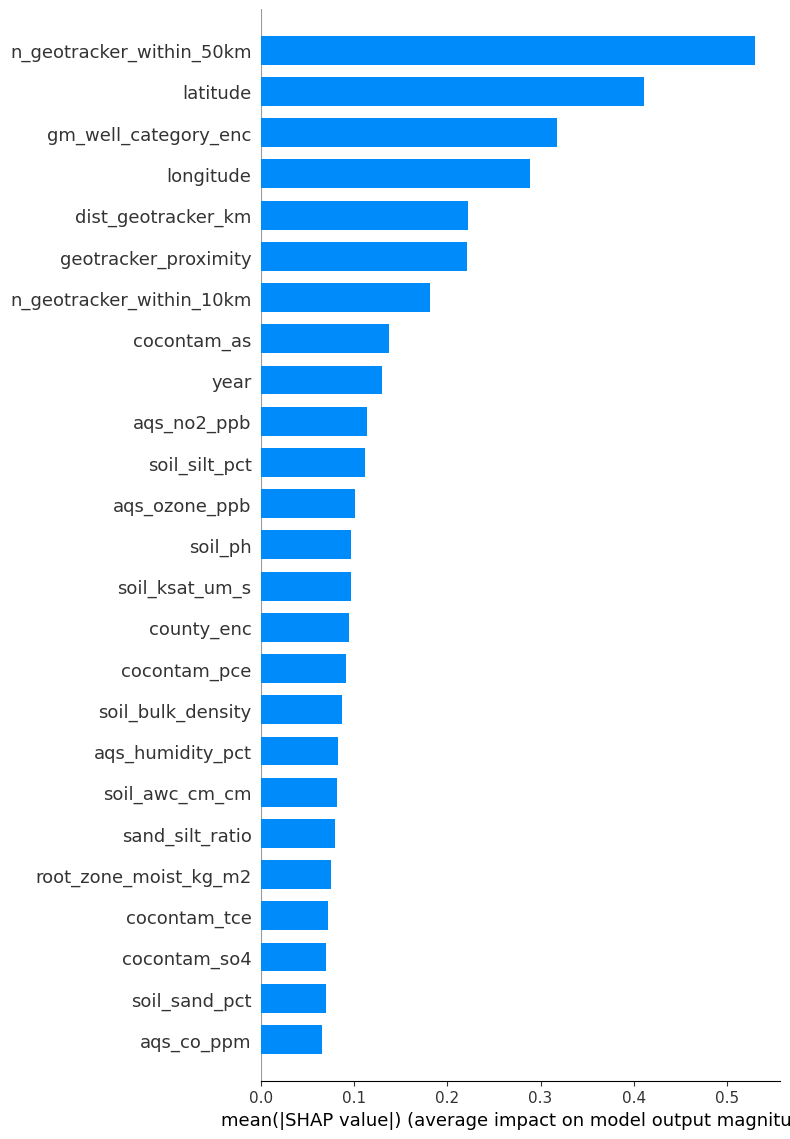

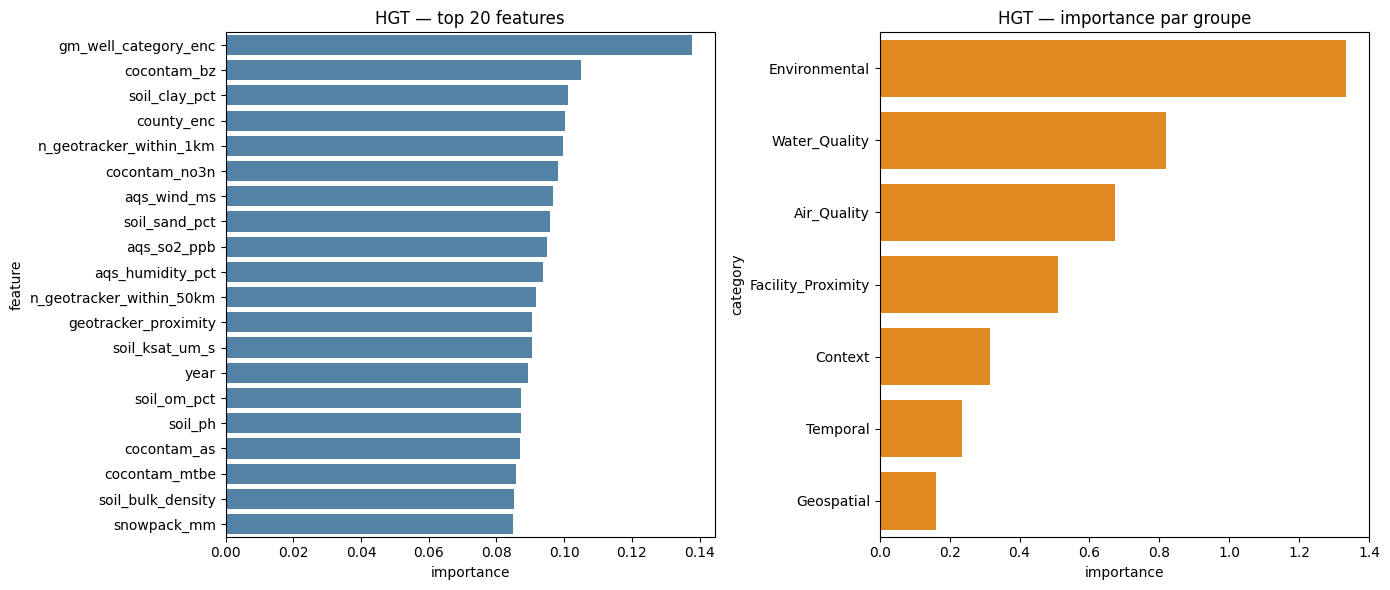

          category  importance
     Environmental    1.334069
     Water_Quality    0.818102
       Air_Quality    0.673613
Facility_Proximity    0.510533
           Context    0.315194
          Temporal    0.235191
        Geospatial    0.161042


In [14]:
import json as _json
def _sanitize(model):
    b = model.get_booster(); cfg = _json.loads(b.save_config()); lp = cfg.get('learner',{}).get('learner_model_param',{}); bs = lp.get('base_score')
    if isinstance(bs,str) and bs.startswith('[') and bs.endswith(']'): lp['base_score'] = bs.strip('[]'); b.load_config(_json.dumps(cfg))
    return b
def get_shap_values_xgb(model, X):
    import shap; b = _sanitize(model)
    try:
        ex = shap.TreeExplainer(b); return ex.shap_values(X), ex.expected_value
    except Exception:
        contrib = b.predict(xgb.DMatrix(X), pred_contribs=True); return contrib[:,:-1], float(np.mean(contrib[:,-1]))
import shap
shap_vals, _ = get_shap_values_xgb(xgb_baseline, X_test_s)
shap.summary_plot(shap_vals, X_test_s, feature_names=list(all_feature_cols), plot_type='bar', max_display=25, show=False)
plt.tight_layout(); plt.savefig(FIG_DIR/'fig8_shap_bar_xgb.png', dpi=300, bbox_inches='tight'); plt.show()

if TORCH_GEOMETRIC_AVAILABLE:
    with torch.no_grad(): w = hgt_model.lin_dict['sample'].weight.cpu().numpy()
    hgt_imp = pd.DataFrame({'feature': all_feature_cols, 'importance': np.mean(np.abs(w),0)}).sort_values('importance', ascending=False)
    cat_imp = []
    for cat, feats in FEATURE_CATEGORIES.items():
        fin = [f for f in feats if f in hgt_imp['feature'].values]
        if fin: cat_imp.append({'category':cat, 'importance':hgt_imp.loc[hgt_imp['feature'].isin(fin),'importance'].sum()})
    cat_imp_df = pd.DataFrame(cat_imp).sort_values('importance', ascending=False)
    fig, ax = plt.subplots(1,2,figsize=(14,6))
    sns.barplot(data=hgt_imp.head(20), x='importance', y='feature', color='steelblue', ax=ax[0]); ax[0].set_title('HGT — top 20 features')
    sns.barplot(data=cat_imp_df, x='importance', y='category', color='darkorange', ax=ax[1]); ax[1].set_title('HGT — importance par groupe')
    plt.tight_layout(); plt.savefig(FIG_DIR/'fig13_hgt_importance.png', dpi=300, bbox_inches='tight'); plt.show()
    print(cat_imp_df.to_string(index=False))

## 14. Sauvegarde

In [15]:
if TORCH_GEOMETRIC_AVAILABLE:
    torch.save({'model_state_dict': hgt_model.state_dict(), 'metadata': train_data.metadata()}, MODELS_DIR/'hgt_improved.pt')
    with open(MODELS_DIR/'xgb_fusion_improved.pkl','wb') as f: pickle.dump(xgb_fusion, f)
    with open(MODELS_DIR/'meta_clf_improved.pkl','wb') as f: pickle.dump(meta_clf, f)
    with open(MODELS_DIR/'scaler_improved.pkl','wb') as f: pickle.dump(scaler, f)
    results.to_csv(RES_DIR/'improved_results.csv', index=False)
    summary = {'target':'is_contaminated (EPA 2024)','n_features':len(all_feature_cols),
               'split':'group by '+('county' if SPATIAL_BLOCKING else 'gm_well_id'),
               'n_train':int(len(y_train)),'n_val':int(len(y_val)),'n_test':int(len(y_test)),
               'scale_pos_weight':scale_pos_weight, 'results':results.to_dict('records'),
               'best_model':results.loc[results['F1@thr'].idxmax(),'Model']}
    with open(RES_DIR/'improved_summary.json','w') as f: json.dump(summary, f, indent=2)
    print('Sauvegardé dans models/ et outputs/hgt_hybrid_improved/')

Sauvegardé dans models/ et outputs/hgt_hybrid_improved/


## Conclusion

Cette version améliore la **rigueur** et la **richesse** du modèle :
- **+28 features** et 3 nouveaux types de nœuds (`air`, `time`, `context`) ;
- **arêtes `sample↔sample` (KNN spatial)** → le HGT exploite enfin la structure du graphe ;
- **split par puits** → fin de la fuite « même puits » : les scores reflètent la
  généralisation réelle à de **nouveaux puits** (plus bas mais honnêtes ; mettre
  `SPATIAL_BLOCKING=True` pour un test inter-comtés encore plus strict) ;
- **sans SMOTE** (`scale_pos_weight`), **stacking out-of-fold**, **seuil optimisé** et
  **calibration isotonique** (suivi par le score de Brier).

Le tableau de comparaison montre l'effet du **seuil optimisé** (F1@0.5 vs F1@thr) et de
la **calibration**. Pour aller plus loin : Optuna sur le HGT (`RUN_OPTUNA_HGT=True`),
GAT/GraphSAGE, CatBoost comme 4ᵉ modèle de base, KNN dans l'espace des features.